In [1]:
# Compare with Ulaby semi-infinite canopy model (Ulaby 2014, p468, Fig. 11-7)
import sys
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
from misc.S2RTR import S2RTR

from VRT import VRT
from MORES import MORES
from init_tools import init_surface_from_mores, init_layer_from_mores
from postprocessing import Mueller2sigma0VH
from AIEM import AIEM
from Prescribedkskaeps import Prescribedkskaeps

mores = MORES()
mores.init_from_model_file("../model.toml")


surface = init_surface_from_mores(AIEM, mores)
layer = Prescribedkskaeps(3e9, 1.0, 1*0.1, 1*0.9, 0.22)

vrt = VRT(surface, layer)
vrt.Mue_volume_nosurface((30, 180, 30, 0))

array([[0.00137261, 0.        , 0.        , 0.        ],
       [0.        , 0.00137261, 0.        , 0.        ],
       [0.        , 0.        , 0.00137261, 0.        ],
       [0.        , 0.        , 0.        , 0.00137261]])

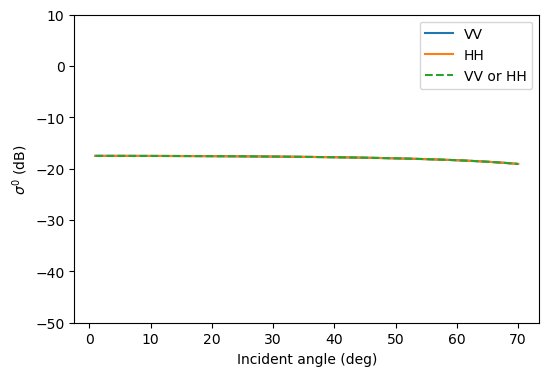

In [2]:
s2rtr_model = S2RTR(f=3e9, d=0.22, ke=1, ks=0.1, scatterer_type='ISOTROPIC')
# run model and plot
theta_is = np.linspace(1, 70, 70)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
sigma0s = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    Mue = vrt.Mue_volume_nosurface((theta_i, 180, theta_i, 0))
    sigma_VV, _, _, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    sigma0_HHs[i] = sigma_HH

    sigma0s[i] = s2rtr_model.sigma0_canopy(theta_i)

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
sigma0s_dB = 10*np.log10(sigma0s)
plt.figure(figsize=(6, 4))
plt.plot(theta_is, sigma0_VV_dB, label='VV')
plt.plot(theta_is, sigma0_HH_dB, label='HH')
plt.plot(theta_is, sigma0s_dB, '--', label='VV or HH')
plt.ylim(-50, 10)
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.show()